# Exploratory Data Analysis (EDA)

---

## Objective

Explore customer purchasing behavior, product performance, and sales patterns to identify actionable business insights.

---

## Business Perspective

Understanding customer and transaction behavior enables businesses to optimize marketing strategies, improve product offerings, and maximize revenue.

Business insights generated from EDA can support:

- Personalized recommendations.
- Cross-selling campaigns.
- Customer retention programs.
- Revenue optimization.

---

## Data Science Perspective

EDA helps identify patterns, anomalies, and hidden relationships within the data.

These insights guide feature engineering, recommendation modeling, and business impact evaluation.

---

## Methodology

The following analyses will be conducted:

1. Customer Analysis.
2. Product Analysis.
3. Revenue Analysis.
4. Country Analysis.
5. Transaction Analysis.
6. Basket Analysis.
7. Temporal Analysis.

---

In [1]:
# ==================================================
# IMPORT LIBRARIES
# ==================================================

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [20]:
# ==================================================
# LOAD CLEAN DATASET
# ==================================================

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "online_retail_clean.csv"
)

df = pd.read_csv(
    DATA_PATH,
    parse_dates=["InvoiceDate"]
)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (392692, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# ==================================================
# CONVERT DATETIME
# ==================================================

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

print(df["InvoiceDate"].dtype)

datetime64[us]


In [5]:
# ==================================================
# CREATE REVENUE FEATURE
# ==================================================

df["Revenue"] = (
    df["Quantity"] *
    df["UnitPrice"]
)

print(
    "Total Revenue:",
    round(df["Revenue"].sum(), 2)
)

Total Revenue: 8887208.89


# Customer Analysis

In [6]:
# ==================================================
# TOP CUSTOMERS
# ==================================================

top_customers = (
    df.groupby("CustomerID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

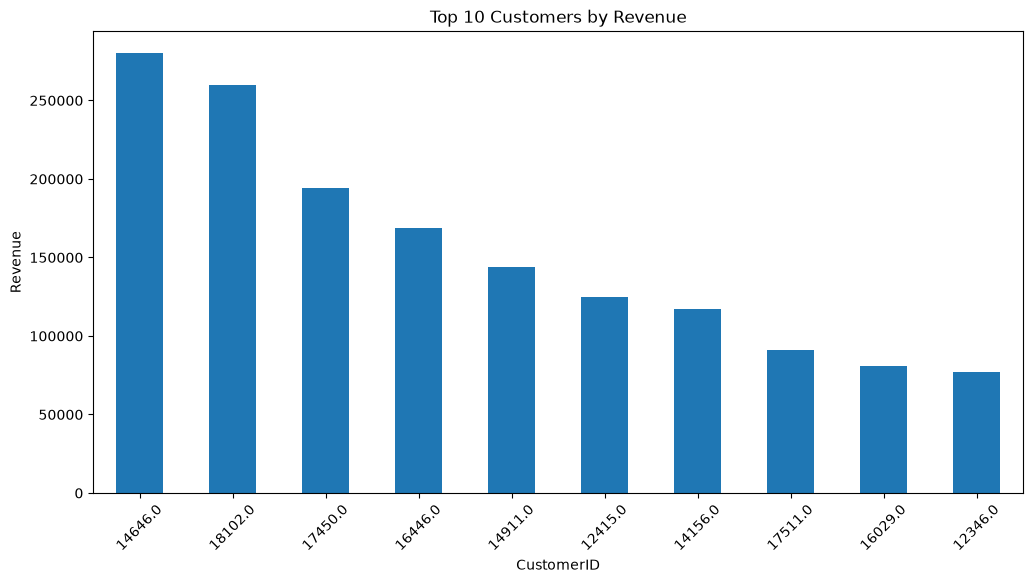

In [7]:
# ==================================================
# TOP CUSTOMER VISUALIZATION
# ==================================================

plt.figure(figsize=(12,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [8]:
# ==================================================
# CUSTOMER PURCHASE DISTRIBUTION
# ==================================================

customer_orders = (
    df.groupby("CustomerID")
      .size()
)

display(customer_orders.describe())

count    4338.000000
mean       90.523744
std       225.506968
min         1.000000
25%        17.000000
50%        41.000000
75%        98.000000
max      7676.000000
dtype: float64

# Product Analysis

In [9]:
# ==================================================
# TOP PRODUCTS BY QUANTITY
# ==================================================

top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

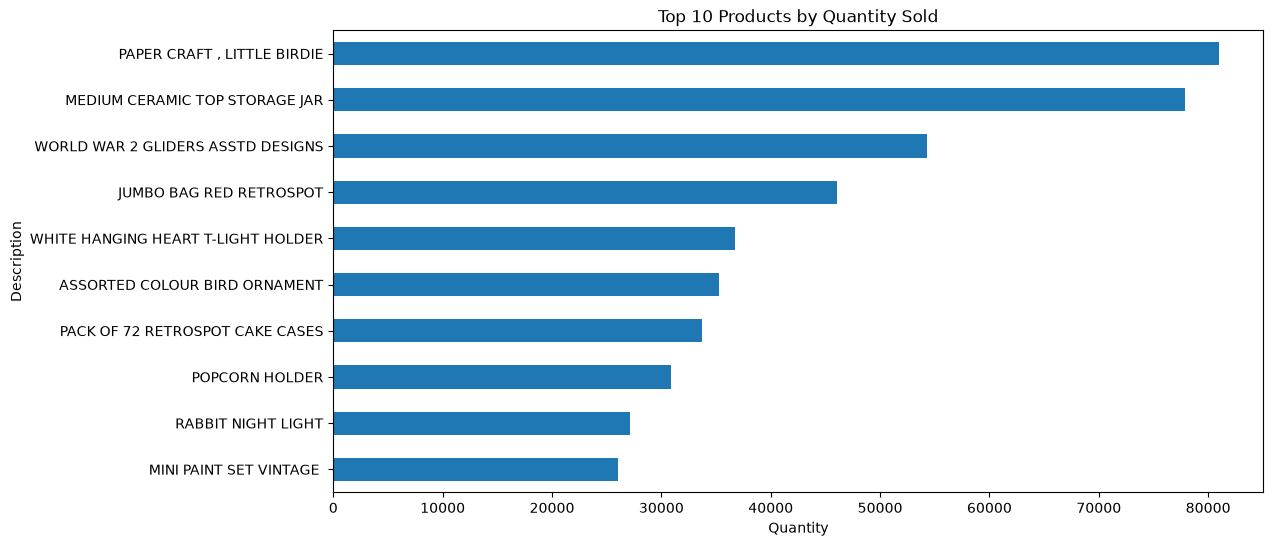

In [10]:
# ==================================================
# TOP PRODUCTS VISUALIZATION
# ==================================================

plt.figure(figsize=(12,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity")

plt.show()

In [11]:
# ==================================================
# TOP REVENUE PRODUCTS
# ==================================================

top_revenue_products = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(top_revenue_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

# Country Analysis

In [12]:
# ==================================================
# COUNTRY REVENUE
# ==================================================

country_revenue = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(country_revenue)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

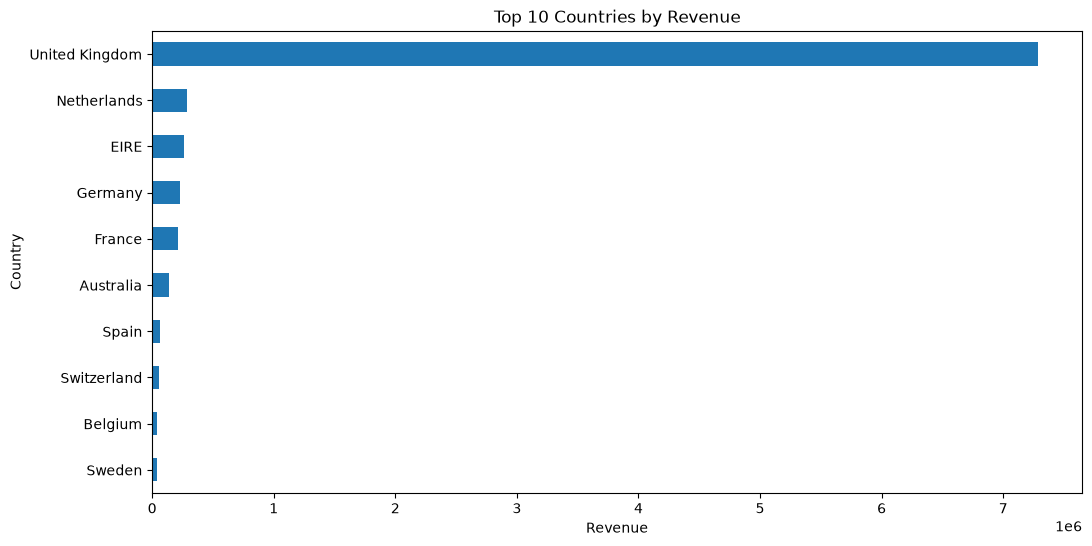

In [13]:
# ==================================================
# COUNTRY REVENUE VISUALIZATION
# ==================================================

plt.figure(figsize=(12,6))

country_revenue.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")

plt.show()

# Time Analysis

In [15]:
# ==================================================
# MONTHLY REVENUE TREND
# ==================================================

df["YearMonth"] = (
    df["InvoiceDate"]
    .dt.to_period("M")
)

monthly_revenue = (
    df.groupby("YearMonth")["Revenue"]
      .sum()
)

display(monthly_revenue)

YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

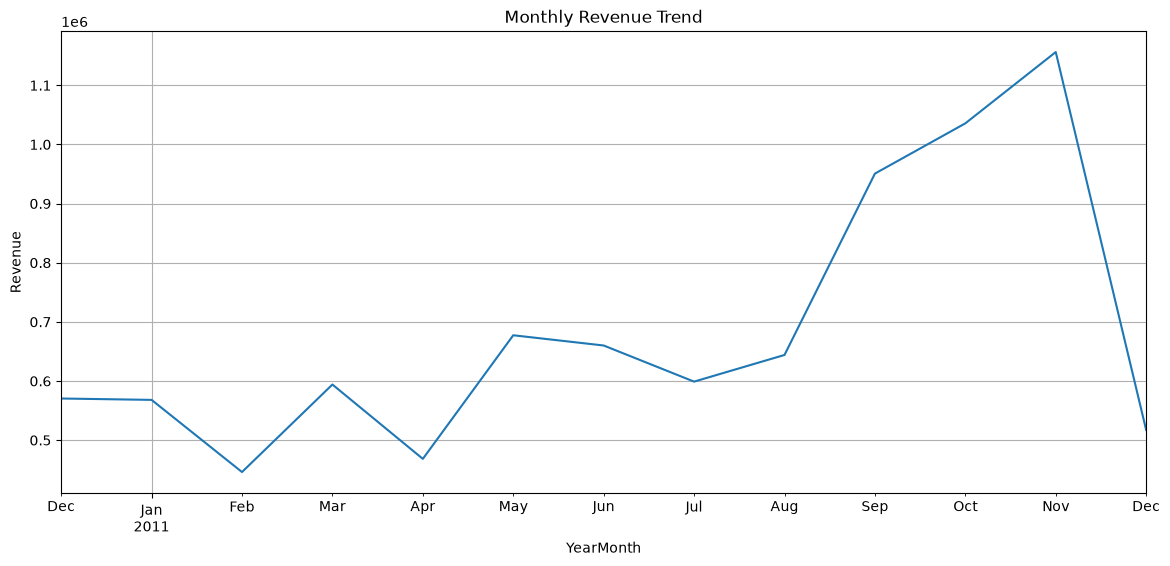

In [16]:
# ==================================================
# MONTHLY REVENUE VISUALIZATION
# ==================================================

plt.figure(figsize=(14,6))

monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")

plt.grid()

plt.show()

In [17]:
# ==================================================
# AVERAGE BASKET SIZE
# ==================================================

basket_size = (
    df.groupby("InvoiceNo")["Quantity"]
      .sum()
)

print(
    "Average Basket Size:",
    round(basket_size.mean(),2)
)

Average Basket Size: 278.01


In [18]:
# ==================================================
# AVERAGE ORDER VALUE
# ==================================================

order_value = (
    df.groupby("InvoiceNo")["Revenue"]
      .sum()
)

print(
    "Average Order Value:",
    round(order_value.mean(),2)
)

Average Order Value: 479.56


# Findings

1. Customer revenue contribution is highly concentrated among a small number of customers.

2. Customer purchasing activity is highly imbalanced, with a few customers generating thousands of transactions.

3. Product popularity distribution is highly skewed, with several products dominating total sales volume.

4. The United Kingdom contributes the majority of company revenue.

5. Monthly revenue exhibits strong seasonality, with revenue peaking during the holiday season.

6. Average basket size is relatively high, indicating strong cross-selling opportunities.

7. Average order value is substantial, suggesting that recommendation improvements may generate significant business impact.

8. The dataset demonstrates characteristics commonly observed in real-world e-commerce businesses.

# Business Insights

1. The business depends heavily on a relatively small number of high-value customers, creating customer concentration risk.

2. Personalized recommendation strategies may significantly increase customer retention among high-value customers.

3. Popular products can be used as baseline recommendations for new customers (cold-start strategy).

4. Seasonal purchasing behavior suggests that recommendation campaigns should be adapted during peak shopping periods.

5. The high average basket size indicates strong opportunities for cross-selling and upselling initiatives.

6. Recommendation systems may increase average order value by encouraging customers to purchase complementary products.

7. Geographic concentration in the United Kingdom should be considered when interpreting recommendation performance.

# Decision

1. Product popularity information will be incorporated into baseline recommendation models.

2. Collaborative filtering techniques will be developed to personalize recommendations.

3. Customer-product interaction matrices will be constructed during feature engineering.

4. Seasonal behavior will be considered during business impact analysis.

5. High-value customers will be further analyzed in future customer segmentation studies.

6. The cleaned dataset is suitable for recommendation model development.